## **ENDUTIH 2022.**

### **MATERIA: ESTADÍSTICA.**

Profesora: Claudia García Blanquel.

Alumno:
- Hernández Martínez Pablo.
- Reyes Calva Angel David.

Grupo: 4AM1.

### **1. Importación de Librerías.**

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

### **2. Carga de datos con factor de expansión (FAC_PER)**

In [7]:
# Cargar el archivo
archivo = "tr_endutih_usuarios2_anual_2022_mod.xlsx"
df_orig = pd.read_excel(archivo, sheet_name=0, engine='openpyxl')

# Columnas a estudiar, ahora incluyendo FAC_PER
cols_w = ["EDAD", "P8_4_2", "SEXO", "ENT", "FAC_PER"]
df_clean_w = df_orig.dropna(subset=cols_w)

# Filtrar los mismos estados (7, 12, 20)
estados = [7, 12, 20]
df_filt_w = df_clean_w[df_clean_w['ENT'].isin(estados)].copy()

### **3. Mismo muestro con factor de expansión.**

In [8]:
# Muestreo estratificadoy la misma lógica
muestras_est_w = []
for estado in estados:
    df_est = df_filt_w[df_filt_w['ENT'] == estado]
    n_muestra = min(100, len(df_est))
    muestra = df_est.sample(n=n_muestra, random_state=42)
    muestras_est_w.append(muestra)

# Unir y conservar solo columnas relevantes
muestra_300_w = pd.concat(muestras_est_w, ignore_index=True)
muestra_300_w = muestra_300_w[["EDAD", "P8_4_2", "SEXO", "FAC_PER"]].copy()
print(f"Muestra ponderada cargada: {len(muestra_300_w)} registros")

Muestra ponderada cargada: 300 registros


### **4. Estimación poblacional de la proporción de smartphone**


ESTIMACIONES POBLACIONALES (USANDO FACTOR DE EXPANSIÓN)
------------------------------------------------------------
Proporción ponderada de smartphone : 0.9009
Error estándar                     : 0.0188
IC 95% poblacional                 : [0.8641, 0.9377]
Proporción muestral (sin ponderar) : 0.8833

Comparación:
La estimación poblacional difiere en 0.0176 respecto a la muestra sin expandir.
La diferencia está dentro del margen de error muestral.


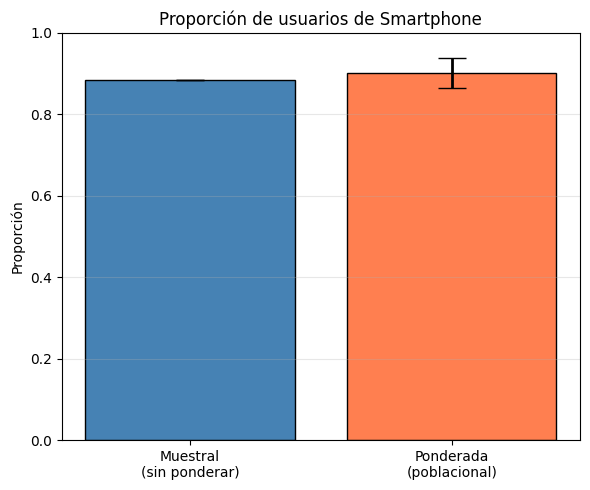

In [9]:
# Convertir P8_4_2 a binario: 1 = Smartphone, 0 = Básico
muestra_300_w['smart'] = (muestra_300_w['P8_4_2'] == 1).astype(int)
w = muestra_300_w['FAC_PER'].values
x = muestra_300_w['smart'].values

# Proporción ponderada
p_hat = np.average(x, weights=w)

# Error estándar ponderado
sum_w = np.sum(w)
se_p = np.sqrt(np.sum(w**2 * (x - p_hat)**2)) / sum_w

# Intervalo de confianza del 95%
z = norm.ppf(0.975)
ic_inf_p = p_hat - z * se_p
ic_sup_p = p_hat + z * se_p

# Proporción muestral sin ponderar
p_muestral = x.mean()

print("\nESTIMACIONES POBLACIONALES (USANDO FACTOR DE EXPANSIÓN)")
print("-" * 60)
print(f"Proporción ponderada de smartphone : {p_hat:.4f}")
print(f"Error estándar                     : {se_p:.4f}")
print(f"IC 95% poblacional                 : [{ic_inf_p:.4f}, {ic_sup_p:.4f}]")
print(f"Proporción muestral (sin ponderar) : {p_muestral:.4f}")

print("\nComparación:")
print(f"La estimación poblacional difiere en {abs(p_hat - p_muestral):.4f} respecto a la muestra sin expandir.")
if ic_inf_p > p_muestral or ic_sup_p < p_muestral:
    print("La diferencia es relevante: el IC poblacional no contiene el valor muestral.")
else:
    print("La diferencia está dentro del margen de error muestral.")

# Datos para el gráfico
categorias = ['Muestral\n(sin ponderar)', 'Ponderada\n(poblacional)']
valores = [p_muestral, p_hat]
# Error solo para la ponderada (la muestral es un valor puntual sin IC)
errores = [0, z * se_p]

plt.figure(figsize=(6, 5))
barras = plt.bar(categorias, valores, color=['steelblue', 'coral'], edgecolor='black')
plt.errorbar(categorias, valores, yerr=errores, fmt='none', capsize=10, color='black', linewidth=2)
plt.title('Proporción de usuarios de Smartphone', fontsize=12)
plt.ylabel('Proporción')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### **5.  Estimaciones poblacionales por sexo**


ESTIMACIONES POR SEXO
------------------------------------------------------------
Hombres:
  Proporción ponderada: 0.8903
  IC 95%: [0.8312, 0.9494]
Mujeres:
  Proporción ponderada: 0.9103
  IC 95%: [0.8650, 0.9556]


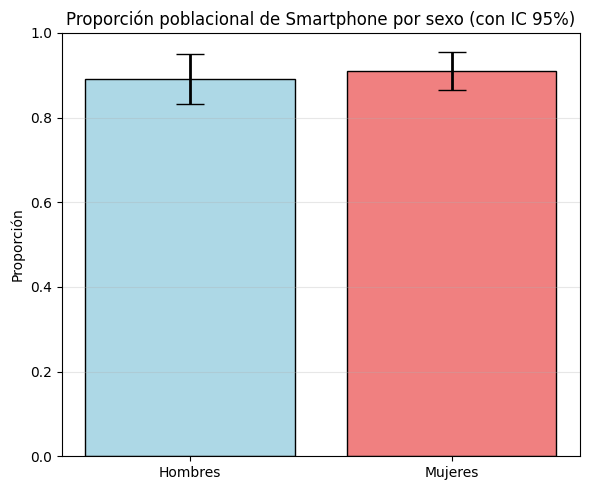

In [10]:
print("\nESTIMACIONES POR SEXO")
print("-" * 60)
for sexo, etiqueta in [(1, 'Hombres'), (2, 'Mujeres')]:
    mask = muestra_300_w['SEXO'] == sexo
    w_sex = w[mask]
    x_sex = x[mask]
    p_sex = np.average(x_sex, weights=w_sex)
    se_sex = np.sqrt(np.sum(w_sex**2 * (x_sex - p_sex)**2)) / np.sum(w_sex)
    ic_inf_sex = p_sex - z * se_sex
    ic_sup_sex = p_sex + z * se_sex
    print(f"{etiqueta}:")
    print(f"  Proporción ponderada: {p_sex:.4f}")
    print(f"  IC 95%: [{ic_inf_sex:.4f}, {ic_sup_sex:.4f}]")

# Proporciones e IC por sexo (ya calculados en la celda anterior)
sexos = ['Hombres', 'Mujeres']
prop_sex = []
ic_errores = []

for sexo, etiqueta in [(1, 'Hombres'), (2, 'Mujeres')]:
    mask = muestra_300_w['SEXO'] == sexo
    w_s = w[mask]
    x_s = x[mask]
    p_s = np.average(x_s, weights=w_s)
    se_s = np.sqrt(np.sum(w_s**2 * (x_s - p_s)**2)) / np.sum(w_s)
    prop_sex.append(p_s)
    ic_errores.append(z * se_s)

plt.figure(figsize=(6, 5))
barras = plt.bar(sexos, prop_sex, color=['lightblue', 'lightcoral'], edgecolor='black')
plt.errorbar(sexos, prop_sex, yerr=ic_errores, fmt='none', capsize=10, color='black', linewidth=2)
plt.title('Proporción poblacional de Smartphone por sexo (con IC 95%)', fontsize=12)
plt.ylabel('Proporción')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()